# **Least Square Method (Performance Metrics)**
# **Maximum Likelihood Estimation and its performance metrics**

**Importing pandas, numpy, matplotlib**

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv",index_col = 0)
data_df.sample(5)

,TV,radio,newspaper,sales
66,69.0,9.3,0.9,9.3
154,171.3,39.7,37.7,19.0
164,163.5,36.8,7.4,18.0
133,8.4,27.2,2.1,5.7
24,228.3,16.9,26.2,15.5


In [14]:
data_df.shape

(200, 4)

# **using Least Square Method (LSM)**

In [6]:
X = data_df.TV.to_numpy().reshape(-1,1)
Y = data_df.sales.to_numpy().reshape(-1,1)

**Using scikit-learn for LinearRegression**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
linear_model = LinearRegression()

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [10]:
X_train.shape

(160, 1)

In [11]:
X_test.shape

(40, 1)

In [12]:
y_train.shape

(160, 1)

In [13]:
y_test.shape

(40, 1)

In [15]:
linear_model.fit(X_train,y_train)

LinearRegression()

In [18]:
linear_model.coef_

array([[0.04652973]])

In [19]:
linear_model.intercept_

array([7.11963843])

**predicting the output**

In [24]:
y_pred = linear_model.predict(X_test)

In [25]:
SSE = np.sum(np.power((y_test - y_pred),2))

In [26]:
SSE

np.float64(408.1861647520383)

**Performance Metrices**

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [30]:
MSE = mean_squared_error(y_test,y_pred)
MSE

10.204654118800956

In [31]:
MAE = mean_absolute_error(y_test,y_pred)
MAE

2.444420003751042

In [33]:
r2 = r2_score(y_test,y_pred)
r2

0.6766954295627076

# **using MLE (Maximum LikeLihood Estimation)**

In [34]:
import matplotlib.pyplot as plt

**observed data**

In [35]:
n = 20
k = 15

**Analytical MLE**

In [36]:
p_hat = k / n
print(f"Analytical MLE = {p_hat:.3f}")

Analytical MLE = 0.750


**Likelihood and Log-Likelihood**

In [ ]:
p = np.linspace(0.001,0.999,500)
p

In [41]:
likelihood = p ** k  * (1-p) ** (n - k)
log_likelihood = k * np.log(p) + (n - k) * np.log(1-p)

best_p = p[np.argmax(log_likelihood)]
print(f"Numerical MLE: {best_p}")

Numerical MLE: 0.749


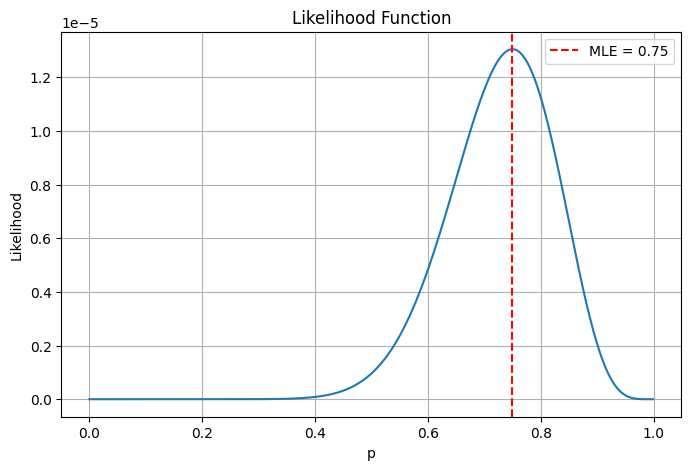

In [42]:
plt.figure(figsize = (8,5))
plt.plot(p, likelihood)
plt.axvline(best_p,color = "red", linestyle = "--",label = f"MLE = {best_p:.2f}")
plt.title("Likelihood Function")
plt.xlabel("p")
plt.ylabel("Likelihood")
plt.grid(True)
plt.legend()
plt.show()

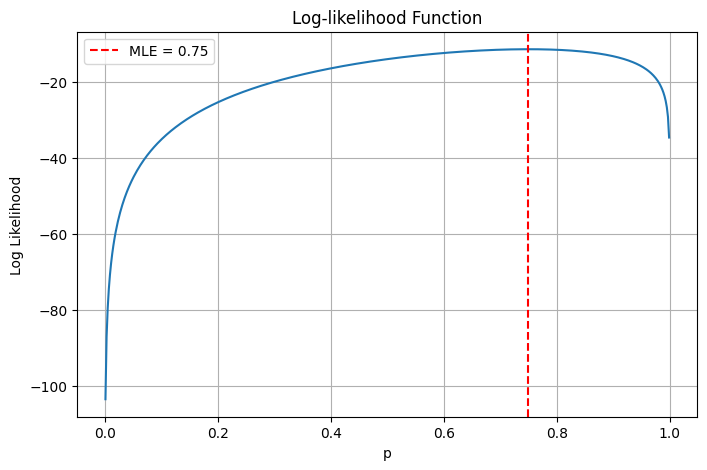

In [43]:
plt.figure(figsize = (8,5))
plt.plot(p,log_likelihood)
plt.axvline(best_p,color = "red",linestyle = "--",label = f"MLE = {best_p:.2f}")
plt.title("Log-likelihood Function")
plt.xlabel("p")
plt.ylabel("Log Likelihood")
plt.grid(True)
plt.legend()
plt.show()